## Customer Churn Prediction and Retention Analysis

### Data Understanding and Initial EDA

Objective:This notebook performs the initial data understanding and exploratory data analysis of the IBM Telco Customer Churn dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%pip install openpyxl

#python -m pip install openpyxl (in terminal)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
file_path = "../data/raw/Telco_customer_churn.xlsx"
df = pd.read_excel(file_path)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
# dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 33


In [8]:
# Data Types and Structure
# Understanding the data types of each feature is an important step before preprocessing. Numerical, categorical, identifier, and target variables require different preprocessing techniques.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [9]:
df.dtypes.value_counts()

object     24
int64       6
float64     3
Name: count, dtype: int64

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()
print("Numerical columns:")
print(numerical_columns)
print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']

Categorical columns:
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label', 'Churn Reason']


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [12]:
#Missing Value Analysis:
#Missing values can affect statistical analysis and machine learning model performance.
#This section identifies missing values in each feature before any imputation or removal is performed.

#Calculate the total number of missing values in the dataset
total_missing = df.isnull().sum().sum()
print("Total missing values:", total_missing)

Total missing values: 5174


In [13]:
# Count missing values in each column
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Churn Reason    5174
dtype: int64


In [15]:
# Calculate missing-value percentage for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})
missing_summary = missing_summary[
    missing_summary['Missing Values'] > 0
].sort_values(
    by='Missing Percentage',
    ascending=False
)
missing_summary

,Missing Values,Missing Percentage
Churn Reason,5174,73.463013


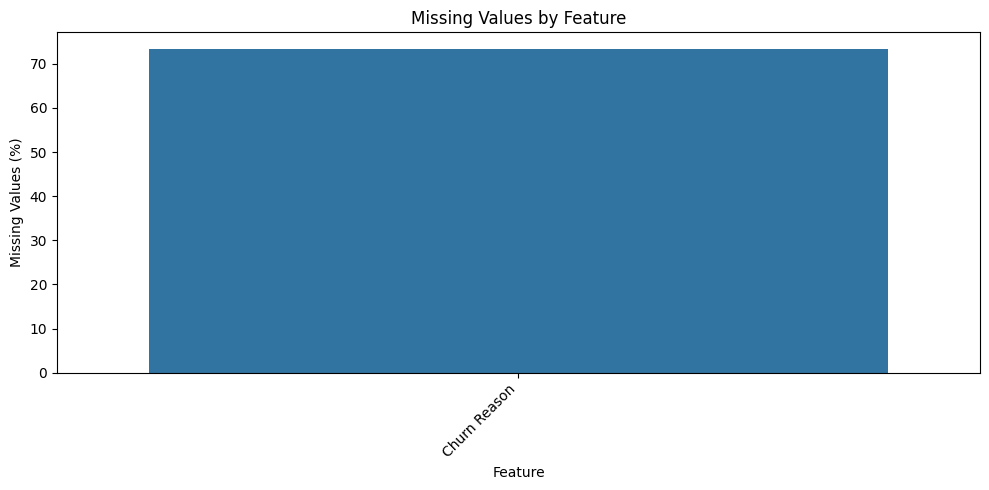

In [16]:
# Visualize columns containing missing values
if not missing_summary.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=missing_summary.index,
        y=missing_summary['Missing Percentage']
    )

    plt.title('Missing Values by Feature')
    plt.xlabel('Feature')
    plt.ylabel('Missing Values (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

In [17]:
# Check for blank or whitespace-only strings
blank_values = {}

for column in df.select_dtypes(include='object').columns:
    blanks = df[column].astype(str).str.strip().eq('').sum()
    if blanks > 0:
        blank_values[column] = blanks

print("Blank string values:")
print(blank_values)

Blank string values:
{'Total Charges': 11}


In [18]:
#Duplicate Record Analysis
#Check for completely duplicated rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


#### Target Variable Analysis

The target variable represents whether a customer has churned. Understanding its distribution is essential for determining the nature of the classification problem and identifying potential class imbalance.
In this project, `Churn Label` will be considered as the primary target variable because it directly represents the customer's churn status.

In [ ]:
# Count customers in each churn category
churn_counts = df['Churn Label'].value_counts()
print("Customer Churn Distribution:")
print(churn_counts)

Customer Churn Distribution:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [20]:
# Calculate the percentage distribution of the target variable
churn_percentage = df['Churn Label'].value_counts(normalize=True) * 100

print("Customer Churn Percentage:")
print(churn_percentage.round(2))

Customer Churn Percentage:
Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


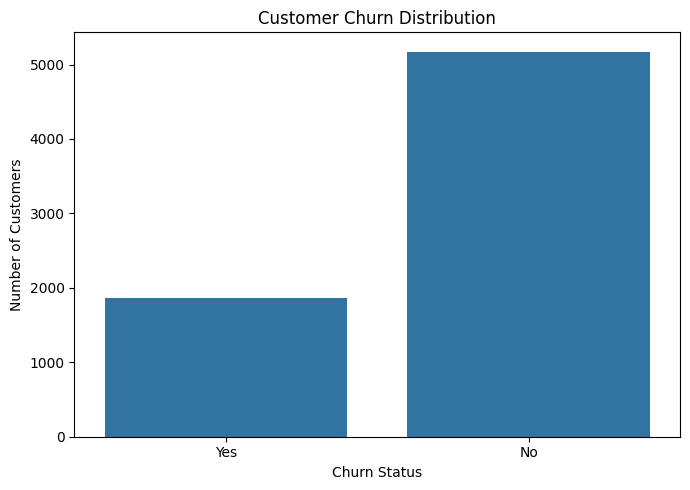

In [21]:
# Visualize customer churn distribution
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Churn Label')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

#### Interpretation

The target variable shows that 5,174 customers (73.46%) did not churn, while 1,869 customers (26.54%) churned.

The distribution indicates a moderate class imbalance, with non-churned customers representing the majority class. This imbalance should be considered during model development because a model that predicts most customers as non-churned could achieve relatively high accuracy while performing poorly at identifying actual churners.

Therefore, model evaluation will place particular emphasis on recall, precision, F1-score, ROC-AUC, and the confusion matrix rather than relying on accuracy alone. Class imbalance handling techniques such as class weighting or resampling will be evaluated during the preprocessing and model development stages.

In [22]:
# Numerical Feature Analysis
# Numerical features provide quantitative information about customer characteristics and account behavior. This section examines the distribution of important numerical variables and explores their relationship with customer churn.
# Define the main numerical features for initial analysis
numerical_features = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges',
    'CLTV'
]

# Display summary statistics
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
Monthly Charges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75
CLTV,7043.0,4400.295755,1183.057152,2003.00,3469.0,4527.00,5380.50,6500.00


In [23]:
# Compare numerical features between churned and non-churned customers
df.groupby('Churn Label')[numerical_features[:2]].mean().round(2)

,Tenure Months,Monthly Charges
Churn Label,,
No,37.57,61.27
Yes,17.98,74.44


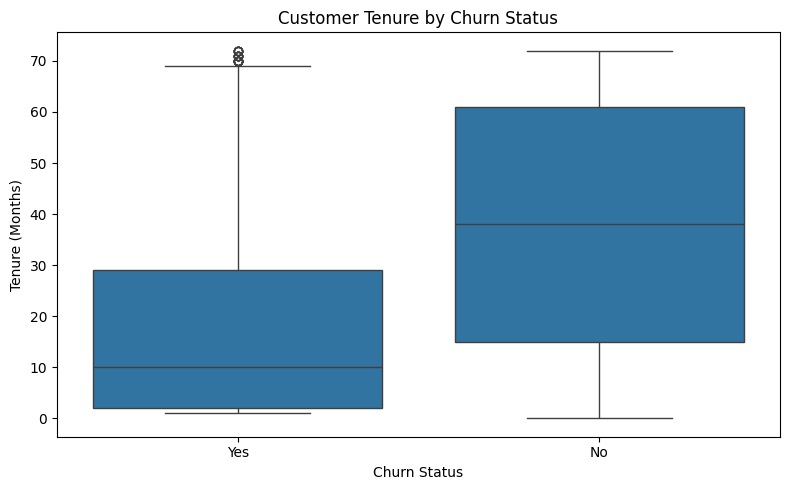

In [24]:
# Distribution of customer tenure by churn status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn Label',
    y='Tenure Months'
)

plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')

plt.tight_layout()
plt.show()

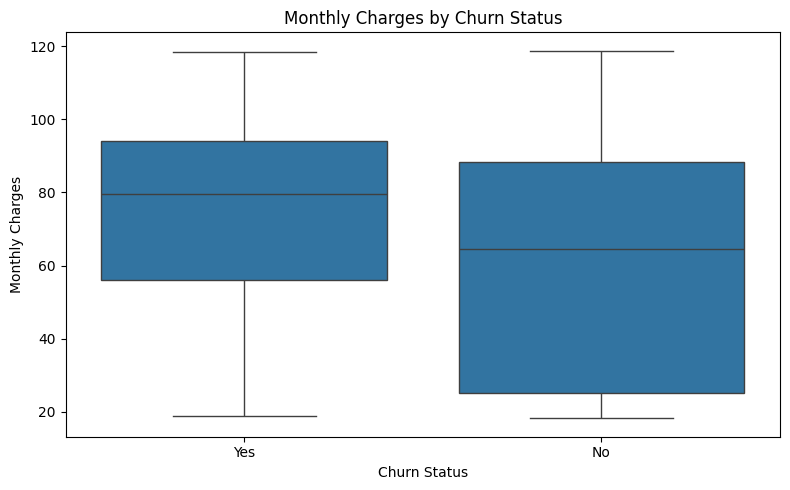

In [25]:
# Distribution of monthly charges by churn status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn Label',
    y='Monthly Charges'
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges')

plt.tight_layout()
plt.show()

In [26]:
# Inspect the values and data type of Total Charges
print("Data type:", df['Total Charges'].dtype)

print("\nSample values:")
print(df['Total Charges'].head(10))

print("\nNon-numeric values:")
total_charges_numeric = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

print(df.loc[
    total_charges_numeric.isna() & df['Total Charges'].notna(),
    'Total Charges'
].unique())

Data type: object

Sample values:
0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
5     528.35
6      39.65
7      20.15
8    4749.15
9       30.2
Name: Total Charges, dtype: object

Non-numeric values:
[' ']


In [27]:
# Examine customers with blank Total Charges
blank_total_charges = df[
    df['Total Charges'].astype(str).str.strip() == ''
]

print("Customers with blank Total Charges:", len(blank_total_charges))

print("\nTenure Months of these customers:")
print(blank_total_charges['Tenure Months'].value_counts())

print("\nChurn status of these customers:")
print(blank_total_charges['Churn Label'].value_counts())

Customers with blank Total Charges: 11

Tenure Months of these customers:
Tenure Months
0    11
Name: count, dtype: int64

Churn status of these customers:
Churn Label
No    11
Name: count, dtype: int64


In [28]:
# Compare Customer Lifetime Value (CLTV) between churned and non-churned customers

df.groupby('Churn Label')['CLTV'].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

,mean,median,min,max
Churn Label,,,,
No,4490.92,4620.0,2003,6500
Yes,4149.41,4238.0,2003,6484


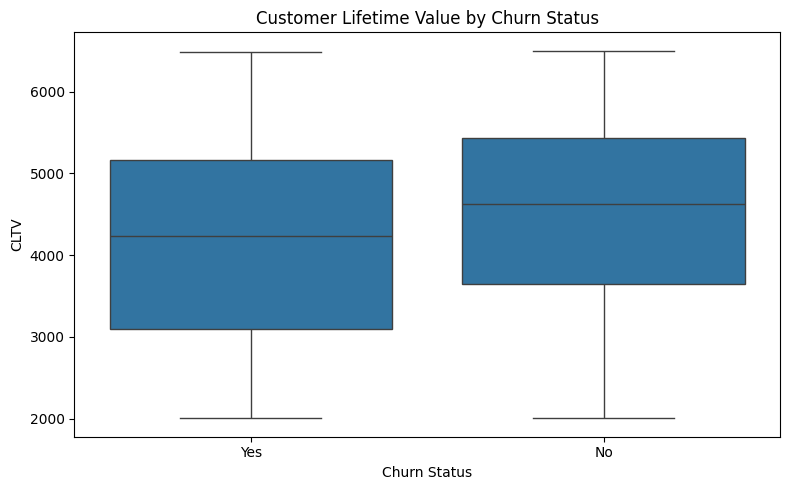

In [29]:
# Distribution of CLTV by churn status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn Label',
    y='CLTV'
)

plt.title('Customer Lifetime Value by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('CLTV')

plt.tight_layout()
plt.show()

#### Categorical Feature Analysis

Categorical variables represent customer characteristics, service choices, and account information. Analyzing these variables against the churn outcome helps identify customer groups that may have different levels of churn risk.
The analysis will focus initially on contract type, internet service, payment method, online security, and technical support because these variables are directly relevant to customer retention.

In [35]:
# Compare Customer Lifetime Value (CLTV) between churned and non-churned customers
#Contract type is an important customer retention variable because the level of contractual commitment may influence the likelihood of a customer leaving the service.

# Count customers by contract type
contract_counts = df['Contract'].value_counts()

print("Customer distribution by contract type:")
print(contract_counts)

Customer distribution by contract type:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


In [33]:
# Count customers by contract type
contract_counts = df['Contract'].value_counts()

print("Customer distribution by contract type:")
print(contract_counts)

Customer distribution by contract type:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


In [36]:
# Calculate churn rate within each contract type
contract_churn_rate = (
    df.groupby('Contract')['Churn Label']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0) * 100
)

contract_churn_rate.round(2)

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


##### Interpretation

The churn rate varies substantially across contract types. Customers with month-to-month contracts have the highest observed churn rate at 42.71%, compared with 11.27% for one-year contracts and only 2.83% for two-year contracts.
This indicates a strong association between contract type and customer churn. Customers with shorter contractual commitments appear considerably more likely to churn than customers with longer-term contracts.

Contract type is therefore expected to be an important feature for the churn prediction model and is also highly relevant to retention strategy. For example, retention efforts could focus on identifying high-risk month-to-month customers and encouraging suitable customers to transition to longer-term contracts.
However, this analysis represents an association within the dataset and does not establish that contract duration directly causes or prevents churn.

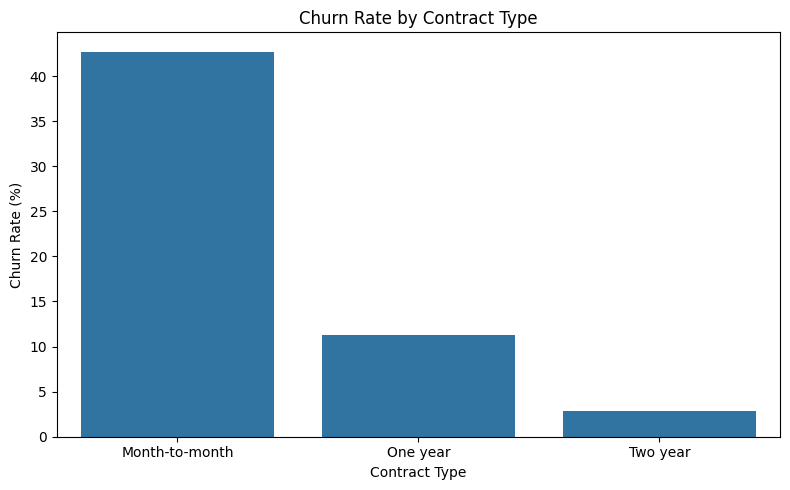

In [37]:
# Visualize churn rate by contract type

contract_churn_yes = contract_churn_rate['Yes'].sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn_yes.index,
    y=contract_churn_yes.values
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [38]:
# Count customers by internet service type
internet_service_counts = df['Internet Service'].value_counts()

print("Customer distribution by internet service:")
print(internet_service_counts)

Customer distribution by internet service:
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


In [39]:
# Calculate churn rate within each internet service type
internet_churn_rate = (
    df.groupby('Internet Service')['Churn Label']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0) * 100
)

internet_churn_rate.round(2)

Churn Label,No,Yes
Internet Service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


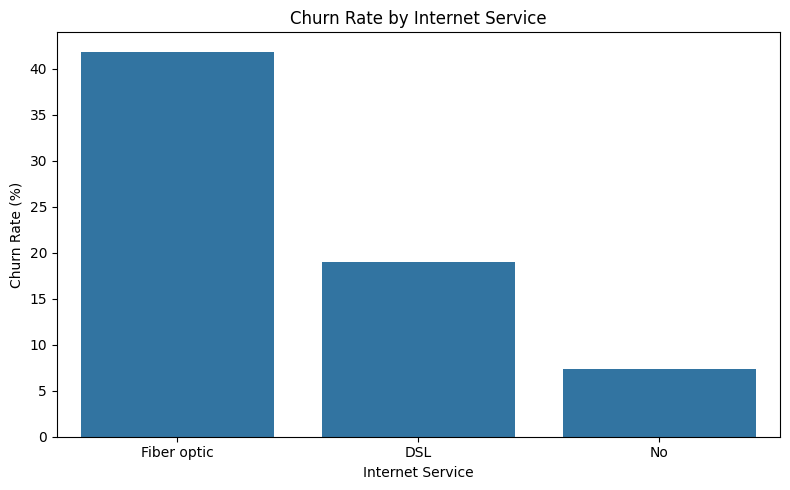

In [40]:
# Visualize churn rate by internet service type

internet_churn_yes = internet_churn_rate['Yes'].sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn_yes.index,
    y=internet_churn_yes.values
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [41]:
# Count customers by payment method
payment_method_counts = df['Payment Method'].value_counts()

print("Customer distribution by payment method:")
print(payment_method_counts)

Customer distribution by payment method:
Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [42]:
# Calculate churn rate within each payment method
payment_churn_rate = (
    df.groupby('Payment Method')['Churn Label']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0) * 100
)

payment_churn_rate.round(2)

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


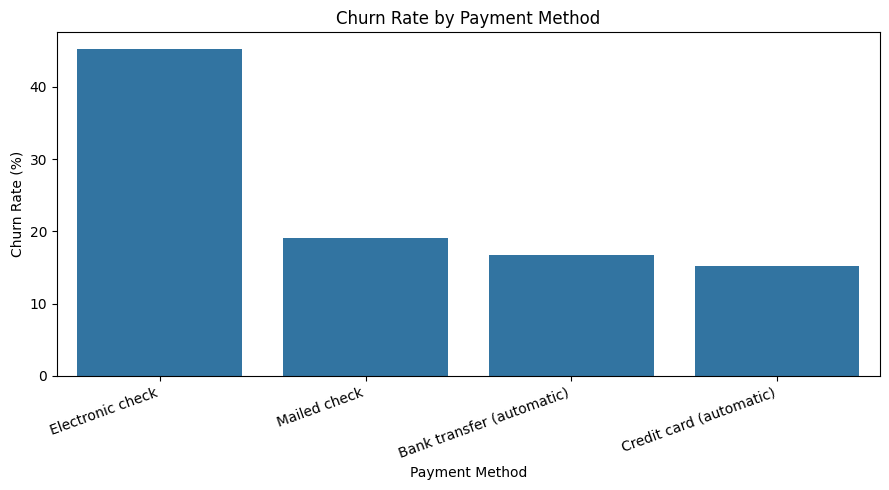

In [43]:
# Visualize churn rate by payment method

payment_churn_yes = payment_churn_rate['Yes'].sort_values(ascending=False)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=payment_churn_yes.index,
    y=payment_churn_yes.values
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [44]:
# Count customers by online security status
online_security_counts = df['Online Security'].value_counts()

print("Customer distribution by online security:")
print(online_security_counts)

Customer distribution by online security:
Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


In [45]:
# Calculate churn rate within each online security category
security_churn_rate = (
    df.groupby('Online Security')['Churn Label']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0) * 100
)

security_churn_rate.round(2)

Churn Label,No,Yes
Online Security,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


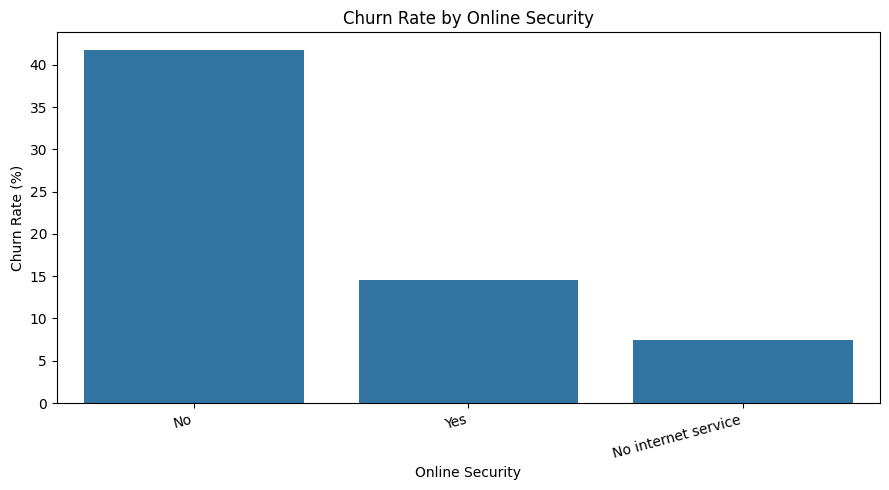

In [46]:
# Visualize churn rate by online security status

security_churn_yes = security_churn_rate['Yes'].sort_values(ascending=False)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=security_churn_yes.index,
    y=security_churn_yes.values
)

plt.title('Churn Rate by Online Security')
plt.xlabel('Online Security')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.show()

In [47]:
# Count customers by technical support status
tech_support_counts = df['Tech Support'].value_counts()

print("Customer distribution by technical support:")
print(tech_support_counts)

Customer distribution by technical support:
Tech Support
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


In [48]:
# Calculate churn rate within each technical support category
tech_support_churn_rate = (
    df.groupby('Tech Support')['Churn Label']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0) * 100
)

tech_support_churn_rate.round(2)

Churn Label,No,Yes
Tech Support,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


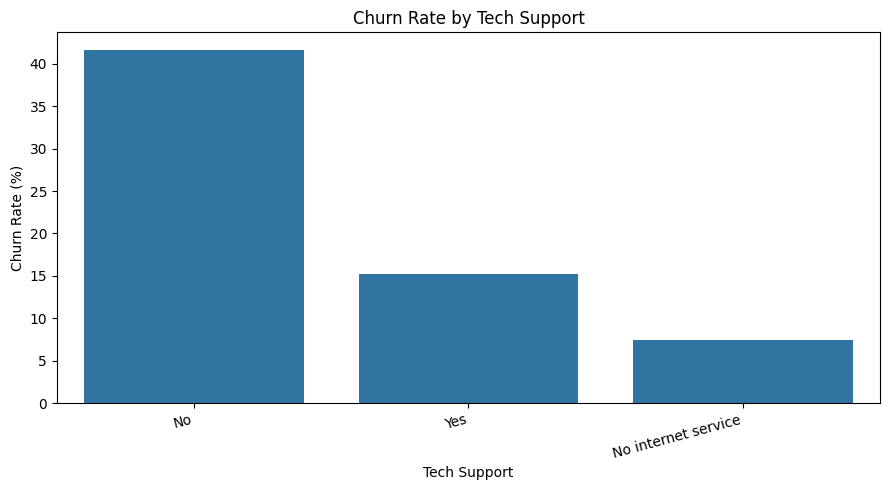

In [49]:
# Visualize churn rate by technical support status

tech_support_churn_yes = tech_support_churn_rate['Yes'].sort_values(
    ascending=False
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=tech_support_churn_yes.index,
    y=tech_support_churn_yes.values
)

plt.title('Churn Rate by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.show()

#### 10. Demographic Feature Analysis

Demographic and household characteristics can provide additional context for understanding customer churn. This section examines selected demographic variables and their relationship with the churn outcome.

In [50]:
# Count customers by senior citizen status
senior_citizen_counts = df['Senior Citizen'].value_counts()

print("Customer distribution by senior citizen status:")
print(senior_citizen_counts)

Customer distribution by senior citizen status:
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64


In [51]:
# Calculate churn rate by senior citizen status
senior_churn_rate = (
    df.groupby('Senior Citizen')['Churn Label']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0) * 100
)

senior_churn_rate.round(2)

Churn Label,No,Yes
Senior Citizen,,
No,76.39,23.61
Yes,58.32,41.68


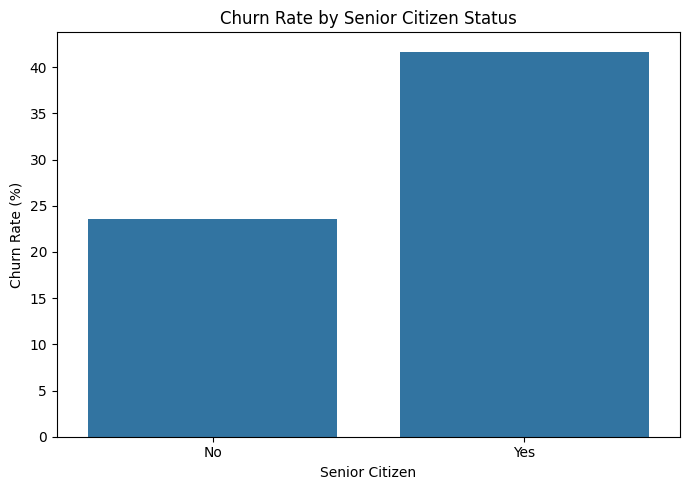

In [52]:
# Visualize churn rate by senior citizen status

senior_churn_yes = senior_churn_rate['Yes']

plt.figure(figsize=(7, 5))

sns.barplot(
    x=senior_churn_yes.index,
    y=senior_churn_yes.values
)

plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [53]:
# Count customers by partner status
partner_counts = df['Partner'].value_counts()

print("Customer distribution by partner status:")
print(partner_counts)

Customer distribution by partner status:
Partner
No     3641
Yes    3402
Name: count, dtype: int64


In [54]:
# Calculate churn rate by partner status
partner_churn_rate = (
    df.groupby('Partner')['Churn Label']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0) * 100
)

partner_churn_rate.round(2)

Churn Label,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


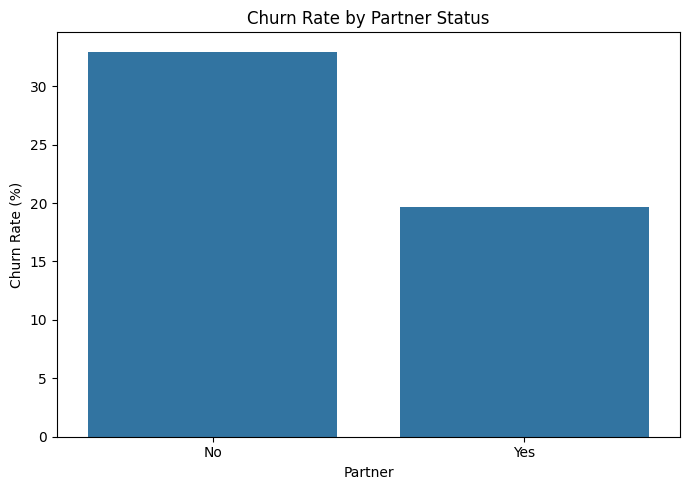

In [55]:
# Visualize churn rate by partner status

partner_churn_yes = partner_churn_rate['Yes']

plt.figure(figsize=(7, 5))

sns.barplot(
    x=partner_churn_yes.index,
    y=partner_churn_yes.values
)

plt.title('Churn Rate by Partner Status')
plt.xlabel('Partner')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [56]:
# Count customers by dependents status
dependents_counts = df['Dependents'].value_counts()

print("Customer distribution by dependents status:")
print(dependents_counts)

Customer distribution by dependents status:
Dependents
No     5416
Yes    1627
Name: count, dtype: int64


In [57]:
# Calculate churn rate by dependents status
dependents_churn_rate = (
    df.groupby('Dependents')['Churn Label']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0) * 100
)

dependents_churn_rate.round(2)

Churn Label,No,Yes
Dependents,,
No,67.45,32.55
Yes,93.48,6.52


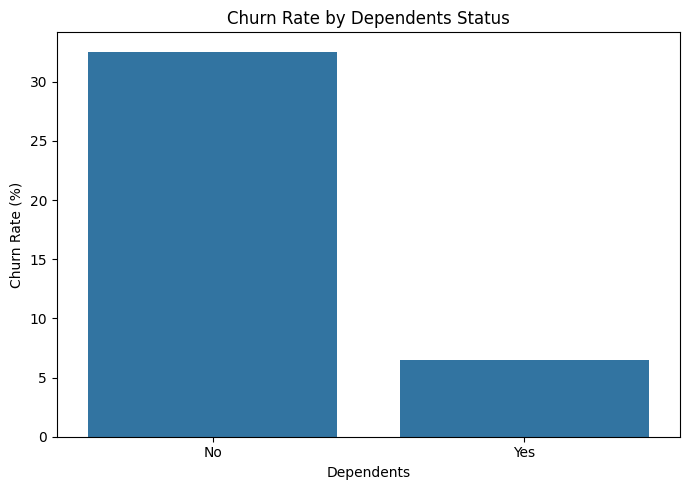

In [58]:
# Visualize churn rate by dependents status

dependents_churn_yes = dependents_churn_rate['Yes']

plt.figure(figsize=(7, 5))

sns.barplot(
    x=dependents_churn_yes.index,
    y=dependents_churn_yes.values
)

plt.title('Churn Rate by Dependents Status')
plt.xlabel('Dependents')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [59]:
# Count customers by gender
gender_counts = df['Gender'].value_counts()

print("Customer distribution by gender:")
print(gender_counts)

Customer distribution by gender:
Gender
Male      3555
Female    3488
Name: count, dtype: int64


In [60]:
# Calculate churn rate by gender
gender_churn_rate = (
    df.groupby('Gender')['Churn Label']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0) * 100
)

gender_churn_rate.round(2)

Churn Label,No,Yes
Gender,,
Female,73.08,26.92
Male,73.84,26.16


#### Contract Type × Churn × Internet Service

The interaction between contract type and internet service is examined to identify customer segments with particularly high or low churn rates. This analysis can provide more actionable insights for customer retention strategies than examining each feature independently.

In [61]:
# Calculate churn rate by contract type and internet service
contract_internet_churn = (
    df.groupby(['Contract', 'Internet Service'])['Churn Label']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0) * 100
)

contract_internet_churn.round(2)

Churn Label                         No    Yes
Contract       Internet Service              
Month-to-month DSL               67.78  32.22
               Fiber optic       45.39  54.61
               No                81.11  18.89
One year       DSL               90.70   9.30
               Fiber optic       80.71  19.29
               No                97.53   2.47
Two year       DSL               98.09   1.91
               Fiber optic       92.77   7.23
               No                99.22   0.78

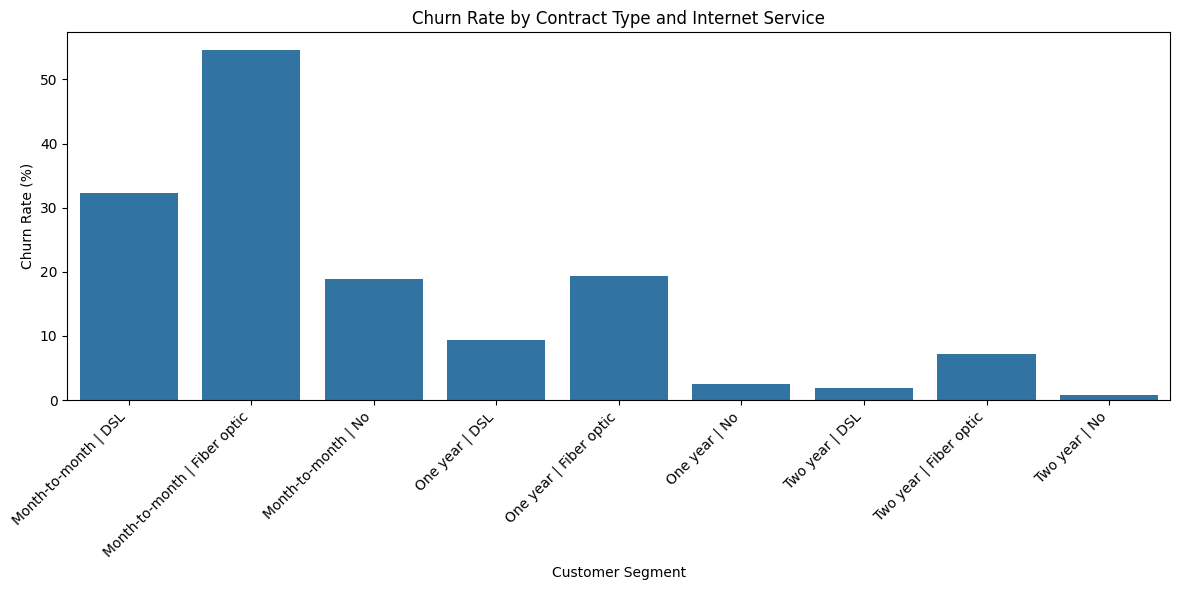

In [62]:
# Prepare data for visualization
contract_internet_plot = (
    contract_internet_churn['Yes']
    .reset_index()
)

contract_internet_plot['Segment'] = (
    contract_internet_plot['Contract']
    + ' | '
    + contract_internet_plot['Internet Service']
)

# Visualize churn rate by contract and internet service
plt.figure(figsize=(12, 6))

sns.barplot(
    data=contract_internet_plot,
    x='Segment',
    y='Yes'
)

plt.title('Churn Rate by Contract Type and Internet Service')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [63]:
# Calculate churn rate by contract type and payment method
contract_payment_churn = (
    df.groupby(['Contract', 'Payment Method'])['Churn Label']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0) * 100
)

contract_payment_churn.round(2)

Churn Label                                  No    Yes
Contract       Payment Method                         
Month-to-month Bank transfer (automatic)  65.87  34.13
               Credit card (automatic)    67.22  32.78
               Electronic check           46.27  53.73
               Mailed check               68.42  31.58
One year       Bank transfer (automatic)  90.28   9.72
               Credit card (automatic)    89.70  10.30
               Electronic check           81.56  18.44
               Mailed check               93.18   6.82
Two year       Bank transfer (automatic)  96.63   3.37
               Credit card (automatic)    97.76   2.24
               Electronic check           92.26   7.74
               Mailed check               99.21   0.79

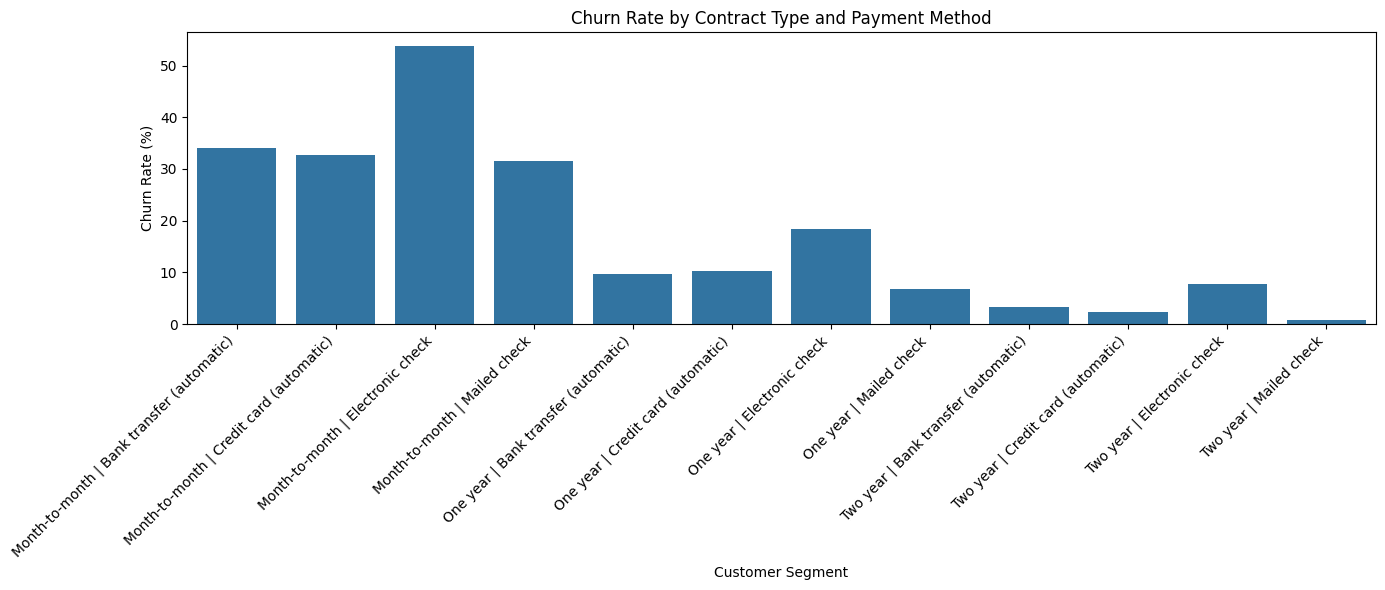

In [64]:
# Prepare data for visualization
contract_payment_plot = (
    contract_payment_churn['Yes']
    .reset_index()
)

contract_payment_plot['Segment'] = (
    contract_payment_plot['Contract']
    + ' | '
    + contract_payment_plot['Payment Method']
)

# Visualize churn rate by contract and payment method
plt.figure(figsize=(14, 6))

sns.barplot(
    data=contract_payment_plot,
    x='Segment',
    y='Yes'
)

plt.title('Churn Rate by Contract Type and Payment Method')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [65]:
# Compare median tenure by contract type and churn status

tenure_contract_churn = (
    df.groupby(['Contract', 'Churn Label'])['Tenure Months']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

tenure_contract_churn

mean  median  min  max
Contract       Churn Label                         
Month-to-month No           21.03    16.0    1   72
               Yes          14.02     7.0    1   71
One year       No           41.67    43.0    0   72
               Yes          44.96    48.0    2   72
Two year       No           56.60    64.0    0   72
               Yes          61.27    65.5   25   72

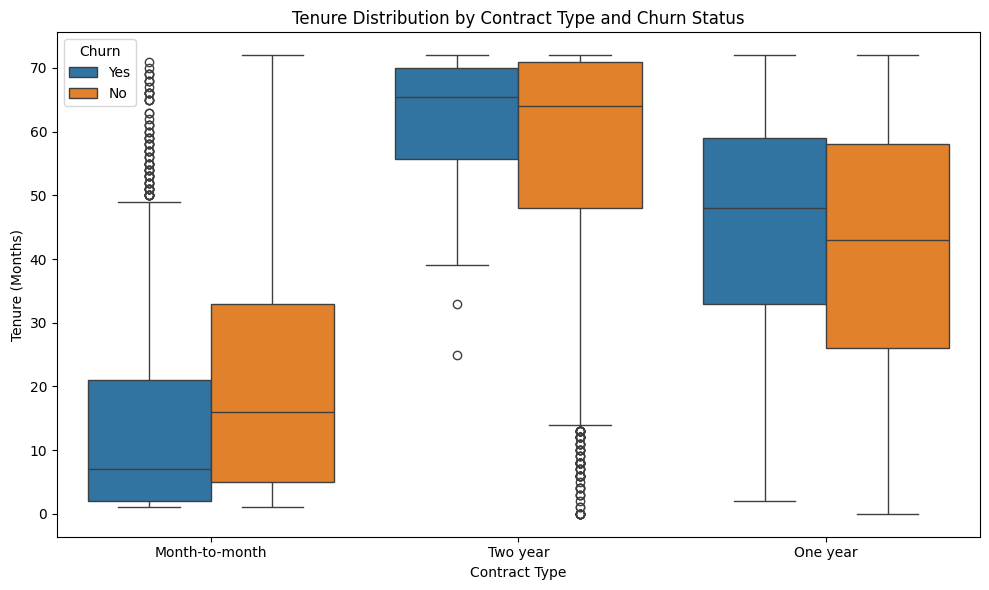

In [66]:
# Visualize tenure distribution by contract type and churn status

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Contract',
    y='Tenure Months',
    hue='Churn Label'
)

plt.title('Tenure Distribution by Contract Type and Churn Status')
plt.xlabel('Contract Type')
plt.ylabel('Tenure (Months)')
plt.legend(title='Churn')

plt.tight_layout()
plt.show()

In [67]:
# Compare monthly charges by contract type and churn status

charges_contract_churn = (
    df.groupby(['Contract', 'Churn Label'])['Monthly Charges']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

charges_contract_churn

mean  median    min     max
Contract       Churn Label                              
Month-to-month No           61.46   64.95  18.75  116.50
               Yes          73.02   79.05  18.85  117.45
One year       No           62.51   64.85  18.25  118.60
               Yes          85.05   95.05  19.30  118.35
Two year       No           60.01   63.30  18.40  118.75
               Yes          86.78   97.28  19.35  116.20

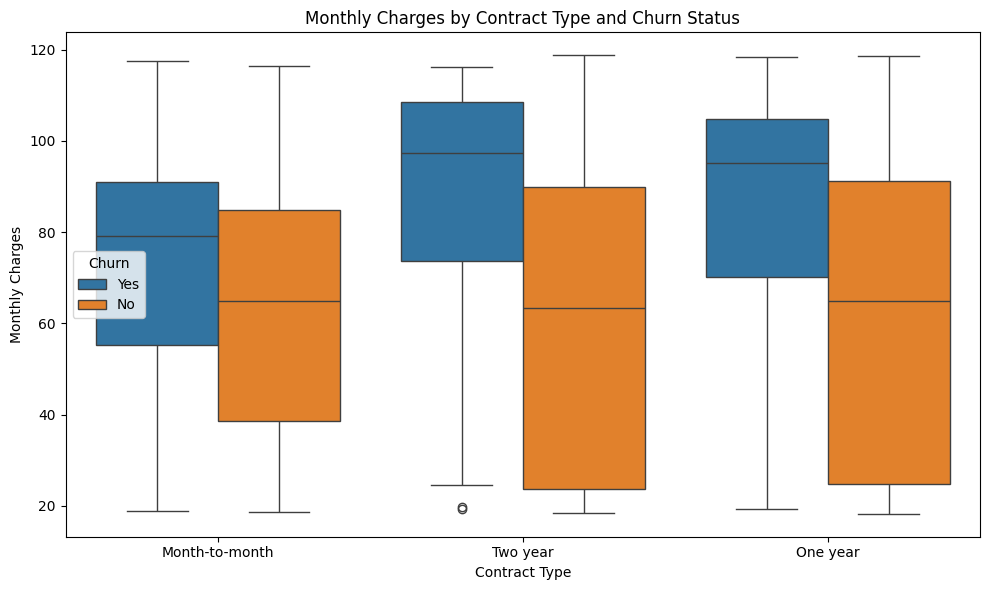

In [68]:
# Visualize monthly charges by contract type and churn status

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Contract',
    y='Monthly Charges',
    hue='Churn Label'
)

plt.title('Monthly Charges by Contract Type and Churn Status')
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charges')
plt.legend(title='Churn')

plt.tight_layout()
plt.show()

### Consolidated EDA Findings

The dataset contains 7,043 customers, with an overall churn rate of 26.54%. The remaining 73.46% of customers did not churn.

#### Categorical Features

Several categorical variables show substantial differences in observed churn rates:
- Month-to-month contract: 42.71%
- Fiber optic internet service: 41.89%
- Electronic check payment: 45.29%
- No online security: 41.77%
- No technical support: 41.64%
- Senior citizens: 41.68%
- Customers without dependents: 32.55%
- Customers without a partner: 32.96%

Gender showed very little difference in churn rates, with 26.92% for females and 26.16% for males.

### Multivariate Findings

Combining multiple variables revealed stronger customer segments than individual feature analysis.
- Month-to-month customers with fiber optic service have a churn rate of 54.61%.
- Month-to-month customers using electronic check have a churn rate of 53.73%.
- Among month-to-month customers, churned customers have a median tenure of 7 months compared with 16 months for non-churned customers.
- Churned customers have higher monthly charges than non-churned customers within every contract category.

### Data Preprocessing

Based on the findings from the exploratory data analysis, the dataset requires several preprocessing steps before machine learning model development.

The preprocessing stage will handle data type conversion, missing values, target encoding, removal of non-predictive identifiers, categorical encoding, and preparation of numerical features.


In [69]:
# Create a separate copy for preprocessing

df_processed = df.copy()

print("Original dataset shape:", df.shape)
print("Preprocessing dataset shape:", df_processed.shape)

Original dataset shape: (7043, 33)
Preprocessing dataset shape: (7043, 33)


In [70]:
# Convert whitespace values to NaN
df_processed['Total Charges'] = (
    df_processed['Total Charges']
    .replace(r'^\s*$', np.nan, regex=True)
)

# Convert the column to numeric
df_processed['Total Charges'] = pd.to_numeric(
    df_processed['Total Charges'],
    errors='coerce'
)

# Replace NaN values with 0 based on EDA findings
df_processed['Total Charges'] = (
    df_processed['Total Charges'].fillna(0)
)

print("Data type after conversion:")
print(df_processed['Total Charges'].dtype)

print("\nMissing values after conversion:")
print(df_processed['Total Charges'].isna().sum())

print("\nSample values:")
print(df_processed['Total Charges'].head())

Data type after conversion:
float64

Missing values after conversion:
0

Sample values:
0     108.15
1     151.65
2     820.50
3    3046.05
4    5036.30
Name: Total Charges, dtype: float64


C:\Users\achal\AppData\Local\Temp\ipykernel_2100\3575250331.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(r'^\s*$', np.nan, regex=True)


In [71]:
# Convert whitespace values to NaN
df_processed['Total Charges'] = (
    df_processed['Total Charges']
    .astype(str)
    .str.strip()
    .replace('', np.nan)
)

# Convert the column to numeric
df_processed['Total Charges'] = pd.to_numeric(
    df_processed['Total Charges'],
    errors='coerce'
)

# Replace missing values with 0 based on EDA findings
df_processed['Total Charges'] = (
    df_processed['Total Charges'].fillna(0)
)

print("Data type after conversion:")
print(df_processed['Total Charges'].dtype)

print("\nMissing values after conversion:")
print(df_processed['Total Charges'].isna().sum())

print("\nSample values:")
print(df_processed['Total Charges'].head())

Data type after conversion:
float64

Missing values after conversion:
0

Sample values:
0     108.15
1     151.65
2     820.50
3    3046.05
4    5036.30
Name: Total Charges, dtype: float64


In [72]:
# Encode the target variable

df_processed['Churn'] = (
    df_processed['Churn Label']
    .map({'No': 0, 'Yes': 1})
)

print("Target value distribution:")
print(df_processed['Churn'].value_counts())

print("\nTarget data type:")
print(df_processed['Churn'].dtype)

Target value distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target data type:
int64


In [73]:
# Display all columns before feature selection

print("Columns in preprocessing dataset:")
for i, column in enumerate(df_processed.columns, start=1):
    print(f"{i}. {column}")

Columns in preprocessing dataset:
1. CustomerID
2. Count
3. Country
4. State
5. City
6. Zip Code
7. Lat Long
8. Latitude
9. Longitude
10. Gender
11. Senior Citizen
12. Partner
13. Dependents
14. Tenure Months
15. Phone Service
16. Multiple Lines
17. Internet Service
18. Online Security
19. Online Backup
20. Device Protection
21. Tech Support
22. Streaming TV
23. Streaming Movies
24. Contract
25. Paperless Billing
26. Payment Method
27. Monthly Charges
28. Total Charges
29. Churn Label
30. Churn Value
31. Churn Score
32. CLTV
33. Churn Reason
34. Churn


In [74]:
# Check Constant / Near-Constant Columns
# Check unique values in potentially non-predictive columns

columns_to_check = [
    'Count',
    'CustomerID',
    'Churn Label',
    'Churn Score',
    'Churn Reason'
]

for column in columns_to_check:
    print(f"\n{column}")
    print("Unique values:", df_processed[column].nunique())
    print("Sample values:")
    print(df_processed[column].drop_duplicates().head(10).tolist())


Count
Unique values: 1
Sample values:
[1]

CustomerID
Unique values: 7043
Sample values:
['3668-QPYBK', '9237-HQITU', '9305-CDSKC', '7892-POOKP', '0280-XJGEX', '4190-MFLUW', '8779-QRDMV', '1066-JKSGK', '6467-CHFZW', '8665-UTDHZ']

Churn Label
Unique values: 2
Sample values:
['Yes', 'No']

Churn Score
Unique values: 85
Sample values:
[86, 67, 84, 89, 78, 100, 92, 77, 97, 74]

Churn Reason
Unique values: 20
Sample values:
['Competitor made better offer', 'Moved', 'Competitor had better devices', 'Competitor offered higher download speeds', 'Competitor offered more data', 'Price too high', 'Product dissatisfaction', 'Service dissatisfaction', 'Lack of self-service on Website', 'Network reliability']


In [75]:
# Define columns that should not be used as model features
columns_to_drop = [
    'CustomerID',
    'Count',
    'Churn Label',
    'Churn Score',
    'Churn Reason',
    'Churn'
]

# Create feature matrix
X = df_processed.drop(columns=columns_to_drop)

# Create target variable
y = df_processed['Churn']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nRemaining feature columns:")
print(X.columns.tolist())

Feature matrix shape: (7043, 28)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Remaining feature columns:
['Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


In [76]:
y = df_processed['Churn']

In [77]:
# Verify whether Churn Value duplicates the target

print("Churn Value unique values:")
print(df_processed['Churn Value'].unique())

print("\nChurn Value distribution:")
print(df_processed['Churn Value'].value_counts())

print("\nDoes Churn Value exactly match Churn?")
print(
    (df_processed['Churn Value'] == df_processed['Churn']).all()
)

Churn Value unique values:
[1 0]

Churn Value distribution:
Churn Value
0    5174
1    1869
Name: count, dtype: int64

Does Churn Value exactly match Churn?
True


#### Remove Non-Predictive and Target-Leakage Features

After verifying the dataset structure, the following columns are excluded from the feature matrix:

- `CustomerID` — unique identifier.
- `Count` — constant feature.
- `Churn Label` — original categorical target.
- `Churn Value` — duplicate numerical representation of the target.
- `Churn Score` — churn-derived score and potential target leakage.
- `Churn Reason` — information available after the churn outcome.
- `Churn` — the target variable, maintained separately as `y`.


In [78]:
# Define columns to exclude from the feature matrix
columns_to_drop = [
    'CustomerID',
    'Count',
    'Churn Label',
    'Churn Value',
    'Churn Score',
    'Churn Reason',
    'Churn'
]

# Recreate feature matrix and target
X = df_processed.drop(columns=columns_to_drop)
y = df_processed['Churn']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nRemaining feature columns:")
print(X.columns.tolist())

Feature matrix shape: (7043, 27)
Target shape: (7043,)

Remaining feature columns:
['Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV']


In [79]:
# Inspect geographic feature cardinality

geographic_columns = [
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude'
]

print("Geographic feature summary:\n")

for column in geographic_columns:
    print(f"{column}:")
    print(f"  Data type: {X[column].dtype}")
    print(f"  Unique values: {X[column].nunique()}")
    print(f"  Missing values: {X[column].isna().sum()}")
    print(f"  Sample values: {X[column].drop_duplicates().head(5).tolist()}")
    print()

Geographic feature summary:

Country:
  Data type: object
  Unique values: 1
  Missing values: 0
  Sample values: ['United States']

State:
  Data type: object
  Unique values: 1
  Missing values: 0
  Sample values: ['California']

City:
  Data type: object
  Unique values: 1129
  Missing values: 0
  Sample values: ['Los Angeles', 'Beverly Hills', 'Huntington Park', 'Lynwood', 'Marina Del Rey']

Zip Code:
  Data type: int64
  Unique values: 1652
  Missing values: 0
  Sample values: [90003, 90005, 90006, 90010, 90015]

Lat Long:
  Data type: object
  Unique values: 1652
  Missing values: 0
  Sample values: ['33.964131, -118.272783', '34.059281, -118.30742', '34.048013, -118.293953', '34.062125, -118.315709', '34.039224, -118.266293']

Latitude:
  Data type: float64
  Unique values: 1652
  Missing values: 0
  Sample values: [33.964131, 34.059281, 34.048013, 34.062125, 34.039224]

Longitude:
  Data type: float64
  Unique values: 1651
  Missing values: 0
  Sample values: [-118.272783, -118

In [80]:
# Remove constant, high-cardinality, and redundant geographic features

geographic_columns_to_drop = [
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long'
]

X = X.drop(columns=geographic_columns_to_drop)

print("Feature matrix shape:", X.shape)

print("\nRemaining geographic features:")
print([
    column for column in ['Latitude', 'Longitude']
    if column in X.columns
])

Feature matrix shape: (7043, 22)

Remaining geographic features:
['Latitude', 'Longitude']


In [81]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nNumber of numerical features:", len(numerical_features))

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

Numerical features:
['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

Number of numerical features: 6

Categorical features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Number of categorical features: 16


In [82]:
# Check the number of unique categories for each categorical feature

categorical_cardinality = (
    X[categorical_features]
    .nunique()
    .sort_values()
)

print("Categorical feature cardinality:\n")
print(categorical_cardinality)

print("\nTotal categorical features:", len(categorical_features))

Categorical feature cardinality:

Gender               2
Senior Citizen       2
Partner              2
Dependents           2
Phone Service        2
Paperless Billing    2
Multiple Lines       3
Internet Service     3
Online Security      3
Online Backup        3
Device Protection    3
Tech Support         3
Streaming TV         3
Streaming Movies     3
Contract             3
Payment Method       4
dtype: int64

Total categorical features: 16


#### Train-Test Split

80/20 split will be used, with stratification based on the target variable to preserve the original churn-class distribution in both subsets.


In [83]:
from sklearn.model_selection import train_test_split

# Split features and target into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Training feature shape: (5634, 22)
Testing feature shape: (1409, 22)

Training target distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [ ]:
#import preprocessing tools
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [85]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [86]:
# Fit the preprocessing transformer using training data only

X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the fitted transformer
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (5634, 49)
Processed testing shape: (1409, 49)


In [87]:
# Get feature names after preprocessing

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed feature names:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Number of processed features: 49

Processed feature names:
1. num__Latitude
2. num__Longitude
3. num__Tenure Months
4. num__Monthly Charges
5. num__Total Charges
6. num__CLTV
7. cat__Gender_Female
8. cat__Gender_Male
9. cat__Senior Citizen_No
10. cat__Senior Citizen_Yes
11. cat__Partner_No
12. cat__Partner_Yes
13. cat__Dependents_No
14. cat__Dependents_Yes
15. cat__Phone Service_No
16. cat__Phone Service_Yes
17. cat__Multiple Lines_No
18. cat__Multiple Lines_No phone service
19. cat__Multiple Lines_Yes
20. cat__Internet Service_DSL
21. cat__Internet Service_Fiber optic
22. cat__Internet Service_No
23. cat__Online Security_No
24. cat__Online Security_No internet service
25. cat__Online Security_Yes
26. cat__Online Backup_No
27. cat__Online Backup_No internet service
28. cat__Online Backup_Yes
29. cat__Device Protection_No
30. cat__Device Protection_No internet service
31. cat__Device Protection_Yes
32. cat__Tech Support_No
33. cat__Tech Support_No internet service
34. cat__Tech Support_

In [88]:
# Final preprocessing validation

print("=== Preprocessing Validation ===")

# Shape validation
print("\nTraining shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

# Missing-value validation
print("\nMissing values in training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in testing data:",
      np.isnan(X_test_processed).sum())

# Target validation
print("\nTraining target classes:")
print(y_train.value_counts())

print("\nTesting target classes:")
print(y_test.value_counts())

# Numerical scaling validation
num_feature_count = len(numerical_features)

print("\nMean of scaled numerical features:")
print(
    X_train_processed[:, :num_feature_count]
    .mean(axis=0)
    .round(4)
)

print("\nStandard deviation of scaled numerical features:")
print(
    X_train_processed[:, :num_feature_count]
    .std(axis=0)
    .round(4)
)

=== Preprocessing Validation ===

Training shape: (5634, 49)
Testing shape: (1409, 49)

Missing values in training data: 0
Missing values in testing data: 0

Training target classes:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target classes:
Churn
0    1035
1     374
Name: count, dtype: int64

Mean of scaled numerical features:
[ 0. -0. -0. -0. -0.  0.]

Standard deviation of scaled numerical features:
[1. 1. 1. 1. 1. 1.]


### Logistic Regression Baseline 

In [89]:
from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully.")

Logistic Regression imported successfully.


In [90]:
# Create Logistic Regression baseline model

logistic_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [91]:
# Generate predictions on the test set

y_pred = logistic_model.predict(X_test_processed)

y_pred_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated successfully.")

print("\nSample predicted classes:")
print(y_pred[:10])

print("\nSample churn probabilities:")
print(y_pred_proba[:10].round(4))

Predictions generated successfully.

Sample predicted classes:
[0 1 0 1 0 1 1 0 0 1]

Sample churn probabilities:
[0.1713 0.8484 0.2265 0.7195 0.0799 0.8047 0.7099 0.1122 0.0037 0.6373]


In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_test, y_pred)

logistic_precision = precision_score(
    y_test,
    y_pred
)

logistic_recall = recall_score(
    y_test,
    y_pred
)

logistic_f1 = f1_score(
    y_test,
    y_pred
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

# Display results
print("Logistic Regression Baseline Performance")
print("----------------------------------------")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-score : {logistic_f1:.4f}")
print(f"ROC-AUC  : {logistic_roc_auc:.4f}")

Logistic Regression Baseline Performance
----------------------------------------
Accuracy : 0.7452
Precision: 0.5131
Recall   : 0.7834
F1-score : 0.6201
ROC-AUC  : 0.8480


Confusion Matrix:
[[757 278]
 [ 81 293]]


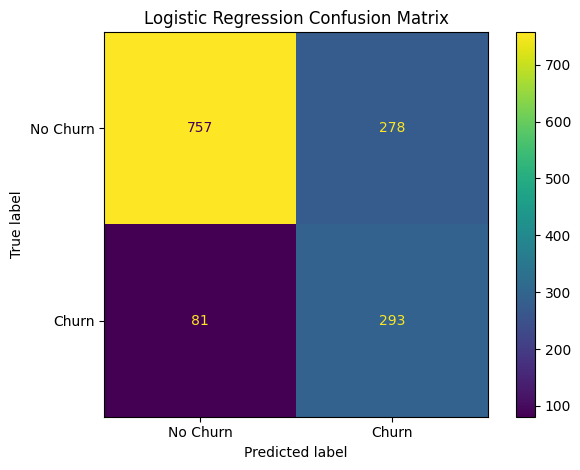

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
logistic_cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(logistic_cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

### Decision Tree Classifier

In [94]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

print("Decision Tree model created successfully.")

Decision Tree model created successfully.


In [95]:
# Train the Decision Tree model

decision_tree_model.fit(
    X_train_processed,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [96]:
# Generate Decision Tree predictions

dt_y_pred = decision_tree_model.predict(X_test_processed)

dt_y_pred_proba = decision_tree_model.predict_proba(
    X_test_processed
)[:, 1]

print("Decision Tree predictions generated successfully.")

print("\nSample predicted classes:")
print(dt_y_pred[:10])

print("\nSample churn probabilities:")
print(dt_y_pred_proba[:10].round(4))

Decision Tree predictions generated successfully.

Sample predicted classes:
[0 1 0 1 0 1 0 0 0 0]

Sample churn probabilities:
[0. 1. 0. 1. 0. 1. 0. 0. 0. 0.]


In [97]:
# Calculate Decision Tree evaluation metrics

dt_accuracy = accuracy_score(y_test, dt_y_pred)

dt_precision = precision_score(
    y_test,
    dt_y_pred
)

dt_recall = recall_score(
    y_test,
    dt_y_pred
)

dt_f1 = f1_score(
    y_test,
    dt_y_pred
)

dt_roc_auc = roc_auc_score(
    y_test,
    dt_y_pred_proba
)

# Display results
print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_roc_auc:.4f}")

Decision Tree Performance
-------------------------
Accuracy : 0.7381
Precision: 0.5066
Recall   : 0.5160
F1-score : 0.5113
ROC-AUC  : 0.6672


In [98]:
DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


### Random Forest Classifier

In [99]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully.")

Random Forest model created successfully.


In [100]:
# Train the Random Forest model

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


In [101]:
# Generate Random Forest predictions

rf_y_pred = random_forest_model.predict(X_test_processed)

rf_y_pred_proba = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest predictions generated successfully.")

print("\nSample predicted classes:")
print(rf_y_pred[:10])

print("\nSample churn probabilities:")
print(rf_y_pred_proba[:10].round(4))

Random Forest predictions generated successfully.

Sample predicted classes:
[0 1 0 0 0 1 0 0 0 0]

Sample churn probabilities:
[0.015 0.76  0.035 0.48  0.03  0.565 0.395 0.16  0.005 0.485]


In [102]:
# Calculate Random Forest evaluation metrics

rf_accuracy = accuracy_score(y_test, rf_y_pred)

rf_precision = precision_score(
    y_test,
    rf_y_pred
)

rf_recall = recall_score(
    y_test,
    rf_y_pred
)

rf_f1 = f1_score(
    y_test,
    rf_y_pred
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_y_pred_proba
)

# Display results
print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.7963
Precision: 0.6485
Recall   : 0.5080
F1-score : 0.5697
ROC-AUC  : 0.8438


### Model Performance Comparison

In [103]:
# Create model comparison dataframe

model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        logistic_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    'Precision': [
        logistic_precision,
        dt_precision,
        rf_precision
    ],
    'Recall': [
        logistic_recall,
        dt_recall,
        rf_recall
    ],
    'F1-Score': [
        logistic_f1,
        dt_f1,
        rf_f1
    ],
    'ROC-AUC': [
        logistic_roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

# Display results as percentages
model_results_display = model_results.copy()

metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

model_results_display[metric_columns] = (
    model_results_display[metric_columns] * 100
).round(2)

model_results_display

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,74.52,51.31,78.34,62.01,84.80
1,Decision Tree,73.81,50.66,51.60,51.13,66.72
2,Random Forest,79.63,64.85,50.80,56.97,84.38


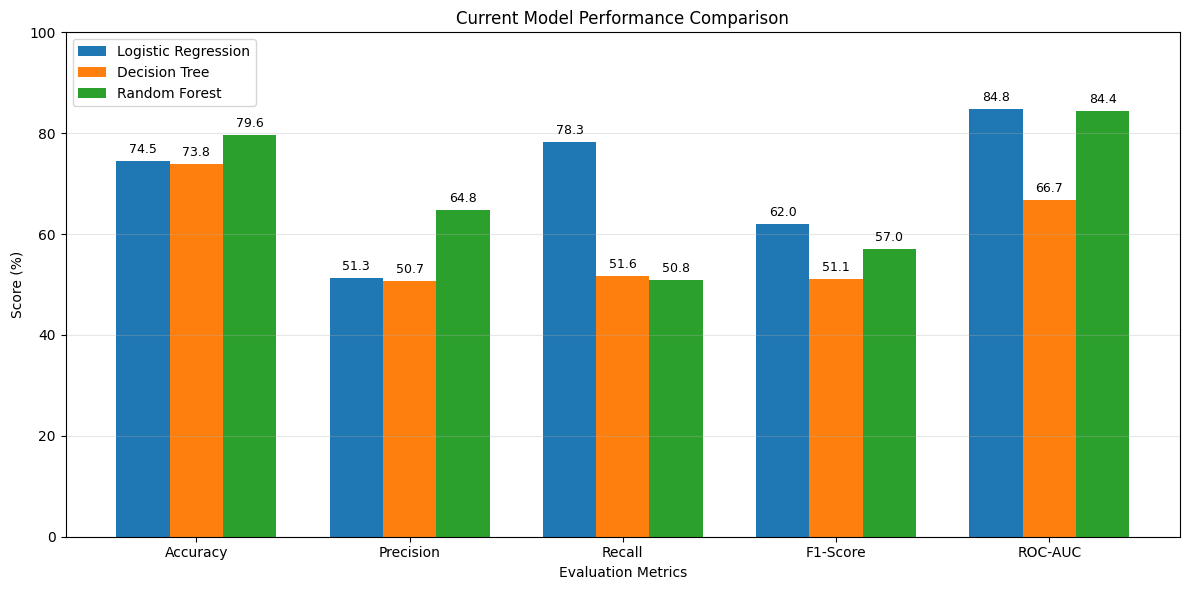

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = model_results['Model'].tolist()

# Metrics
metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

# Convert metric values to percentages
performance = model_results[metrics].values * 100

# Set positions
x = np.arange(len(metrics))
width = 0.25

# Create figure
plt.figure(figsize=(12, 6))

# Plot bars
for i, model in enumerate(models):
    plt.bar(
        x + (i - 1) * width,
        performance[i],
        width,
        label=model
    )

# Formatting
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score (%)')
plt.title('Current Model Performance Comparison')
plt.xticks(x, metrics)
plt.ylim(0, 100)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i in range(len(models)):
    for j in range(len(metrics)):
        plt.text(
            x[j] + (i - 1) * width,
            performance[i, j] + 1,
            f'{performance[i, j]:.1f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

### Gradient Boosting 

In [104]:
from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting model
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

print("Gradient Boosting model created successfully.")

Gradient Boosting model created successfully.


In [106]:
# Train the Gradient Boosting model

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [107]:
# Generate Gradient Boosting predictions

gb_y_pred = gradient_boosting_model.predict(
    X_test_processed
)

gb_y_pred_proba = gradient_boosting_model.predict_proba(
    X_test_processed
)[:, 1]

print("Gradient Boosting predictions generated successfully.")

print("\nSample predicted classes:")
print(gb_y_pred[:10])

print("\nSample churn probabilities:")
print(gb_y_pred_proba[:10].round(4))

Gradient Boosting predictions generated successfully.

Sample predicted classes:
[0 1 0 0 0 1 0 0 0 0]

Sample churn probabilities:
[0.0459 0.7995 0.0925 0.4782 0.0333 0.6274 0.4811 0.0555 0.0116 0.371 ]


In [108]:
# Calculate Gradient Boosting evaluation metrics

gb_accuracy = accuracy_score(y_test, gb_y_pred)

gb_precision = precision_score(
    y_test,
    gb_y_pred
)

gb_recall = recall_score(
    y_test,
    gb_y_pred
)

gb_f1 = f1_score(
    y_test,
    gb_y_pred
)

gb_roc_auc = roc_auc_score(
    y_test,
    gb_y_pred_proba
)

# Display results
print("Gradient Boosting Performance")
print("-----------------------------")
print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1-score : {gb_f1:.4f}")
print(f"ROC-AUC  : {gb_roc_auc:.4f}")

Gradient Boosting Performance
-----------------------------
Accuracy : 0.8013
Precision: 0.6567
Recall   : 0.5267
F1-score : 0.5846
ROC-AUC  : 0.8497


### Model Comparison & Selection

In [109]:
# Create a ranked model comparison

model_ranking = model_results.copy()

# Calculate a simple composite score using F1 and ROC-AUC
model_ranking['Composite Score'] = (
    0.5 * model_ranking['F1-Score'] +
    0.5 * model_ranking['ROC-AUC']
)

# Rank models by composite score
model_ranking = model_ranking.sort_values(
    by='Composite Score',
    ascending=False
).reset_index(drop=True)

# Display as percentages
model_ranking_display = model_ranking.copy()

percentage_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC',
    'Composite Score'
]

model_ranking_display[percentage_columns] = (
    model_ranking_display[percentage_columns] * 100
).round(2)

model_ranking_display

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Composite Score
0,Logistic Regression,74.52,51.31,78.34,62.01,84.80,73.41
1,Random Forest,79.63,64.85,50.80,56.97,84.38,70.68
2,Decision Tree,73.81,50.66,51.60,51.13,66.72,58.92


In [110]:
# Update model comparison with Gradient Boosting

model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        logistic_accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    'Precision': [
        logistic_precision,
        dt_precision,
        rf_precision,
        gb_precision
    ],
    'Recall': [
        logistic_recall,
        dt_recall,
        rf_recall,
        gb_recall
    ],
    'F1-Score': [
        logistic_f1,
        dt_f1,
        rf_f1,
        gb_f1
    ],
    'ROC-AUC': [
        logistic_roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        gb_roc_auc
    ]
})

# Calculate preliminary composite score
model_results['Composite Score'] = (
    0.5 * model_results['F1-Score'] +
    0.5 * model_results['ROC-AUC']
)

# Rank models by composite score
model_ranking = (
    model_results
    .sort_values(
        by='Composite Score',
        ascending=False
    )
    .reset_index(drop=True)
)

# Display as percentages
model_ranking_display = model_ranking.copy()

percentage_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC',
    'Composite Score'
]

model_ranking_display[percentage_columns] = (
    model_ranking_display[percentage_columns] * 100
).round(2)

model_ranking_display

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Composite Score
0,Logistic Regression,74.52,51.31,78.34,62.01,84.80,73.41
1,Gradient Boosting,80.13,65.67,52.67,58.46,84.97,71.72
2,Random Forest,79.63,64.85,50.80,56.97,84.38,70.68
3,Decision Tree,73.81,50.66,51.60,51.13,66.72,58.92


### Hyperparameter Tuning

In [111]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

print("Hyperparameter tuning tools imported successfully.")

Hyperparameter tuning tools imported successfully.


In [112]:
# Create stratified 5-fold cross-validation

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold stratified cross-validation configured successfully.")

5-fold stratified cross-validation configured successfully.


In [113]:
# Create Logistic Regression pipeline

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        )
    )
])

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [114]:
# Define Logistic Regression hyperparameter grid

logistic_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

print("Logistic Regression parameter grid:")
print(logistic_param_grid)

Logistic Regression parameter grid:
{'model__C': [0.01, 0.1, 1, 10, 100]}


In [115]:
# Perform GridSearchCV for Logistic Regression

logistic_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

logistic_grid_search.fit(
    X_train,
    y_train
)

print("\nLogistic Regression tuning completed.")

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Logistic Regression tuning completed.


In [116]:
print("Best Logistic Regression parameters:")
print(logistic_grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(round(logistic_grid_search.best_score_, 4))

Best Logistic Regression parameters:
{'model__C': 0.1}

Best cross-validation F1-score:
0.639


###  Gradient Boosting Hyperparameter Tuning

In [117]:
# Create Gradient Boosting pipeline

gradient_boosting_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        GradientBoostingClassifier(
            random_state=42
        )
    )
])

print("Gradient Boosting pipeline created successfully.")

Gradient Boosting pipeline created successfully.


In [118]:
# Define Gradient Boosting hyperparameter grid

gradient_boosting_param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3, 4]
}

print("Gradient Boosting parameter grid:")
print(gradient_boosting_param_grid)

Gradient Boosting parameter grid:
{'model__n_estimators': [50, 100, 150], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3, 4]}


In [119]:
# Perform GridSearchCV for Gradient Boosting

gradient_boosting_grid_search = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gradient_boosting_param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

gradient_boosting_grid_search.fit(
    X_train,
    y_train
)

print("\nGradient Boosting tuning completed.")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Gradient Boosting tuning completed.


In [120]:
print("Best Gradient Boosting parameters:")
print(gradient_boosting_grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(round(gradient_boosting_grid_search.best_score_, 4))

Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 150}

Best cross-validation F1-score:
0.6124


In [121]:
logistic_grid_search.best_estimator_
gradient_boosting_grid_search.best_estimator_

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [122]:
# Get the best tuned models

best_logistic_model = logistic_grid_search.best_estimator_
best_gradient_boosting_model = gradient_boosting_grid_search.best_estimator_

# Generate Logistic Regression predictions
tuned_lr_y_pred = best_logistic_model.predict(X_test)

tuned_lr_y_proba = best_logistic_model.predict_proba(X_test)[:, 1]

# Generate Gradient Boosting predictions
tuned_gb_y_pred = best_gradient_boosting_model.predict(X_test)

tuned_gb_y_proba = best_gradient_boosting_model.predict_proba(X_test)[:, 1]

print("Tuned model predictions generated successfully.")

Tuned model predictions generated successfully.


In [123]:
# Evaluate tuned Logistic Regression

tuned_lr_accuracy = accuracy_score(y_test, tuned_lr_y_pred)
tuned_lr_precision = precision_score(y_test, tuned_lr_y_pred)
tuned_lr_recall = recall_score(y_test, tuned_lr_y_pred)
tuned_lr_f1 = f1_score(y_test, tuned_lr_y_pred)
tuned_lr_roc_auc = roc_auc_score(y_test, tuned_lr_y_proba)


# Evaluate tuned Gradient Boosting

tuned_gb_accuracy = accuracy_score(y_test, tuned_gb_y_pred)
tuned_gb_precision = precision_score(y_test, tuned_gb_y_pred)
tuned_gb_recall = recall_score(y_test, tuned_gb_y_pred)
tuned_gb_f1 = f1_score(y_test, tuned_gb_y_pred)
tuned_gb_roc_auc = roc_auc_score(y_test, tuned_gb_y_proba)


# Display results

print("Tuned Logistic Regression Performance")
print("-------------------------------------")
print(f"Accuracy : {tuned_lr_accuracy:.4f}")
print(f"Precision: {tuned_lr_precision:.4f}")
print(f"Recall   : {tuned_lr_recall:.4f}")
print(f"F1-score : {tuned_lr_f1:.4f}")
print(f"ROC-AUC  : {tuned_lr_roc_auc:.4f}")

print("\nTuned Gradient Boosting Performance")
print("-----------------------------------")
print(f"Accuracy : {tuned_gb_accuracy:.4f}")
print(f"Precision: {tuned_gb_precision:.4f}")
print(f"Recall   : {tuned_gb_recall:.4f}")
print(f"F1-score : {tuned_gb_f1:.4f}")
print(f"ROC-AUC  : {tuned_gb_roc_auc:.4f}")

Tuned Logistic Regression Performance
-------------------------------------
Accuracy : 0.7417
Precision: 0.5088
Recall   : 0.7701
F1-score : 0.6128
ROC-AUC  : 0.8479

Tuned Gradient Boosting Performance
-----------------------------------
Accuracy : 0.7984
Precision: 0.6490
Recall   : 0.5241
F1-score : 0.5799
ROC-AUC  : 0.8506


In [125]:
# Final model comparison

final_model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression (Baseline)',
        'Logistic Regression (Tuned)',
        'Gradient Boosting (Baseline)',
        'Gradient Boosting (Tuned)'
    ],
    'Accuracy': [
        logistic_accuracy,
        tuned_lr_accuracy,
        gb_accuracy,
        tuned_gb_accuracy
    ],
    'Precision': [
        logistic_precision,
        tuned_lr_precision,
        gb_precision,
        tuned_gb_precision
    ],
    'Recall': [
        logistic_recall,
        tuned_lr_recall,
        gb_recall,
        tuned_gb_recall
    ],
    'F1-Score': [
        logistic_f1,
        tuned_lr_f1,
        gb_f1,
        tuned_gb_f1
    ],
    'ROC-AUC': [
        logistic_roc_auc,
        tuned_lr_roc_auc,
        gb_roc_auc,
        tuned_gb_roc_auc
    ]
})

final_model_results_display = final_model_results.copy()

metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

final_model_results_display[metric_columns] = (
    final_model_results_display[metric_columns] * 100
).round(2)

final_model_results_display

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),74.52,51.31,78.34,62.01,84.80
1,Logistic Regression (Tuned),74.17,50.88,77.01,61.28,84.79
2,Gradient Boosting (Baseline),80.13,65.67,52.67,58.46,84.97
3,Gradient Boosting (Tuned),79.84,64.90,52.41,57.99,85.06


### Probability Threshold Analysis

In [126]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

thresholds = np.arange(0.20, 0.81, 0.05)

for threshold in thresholds:

    threshold_pred = (
        y_pred_proba >= threshold
    ).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        'F1-Score': f1_score(
            y_test,
            threshold_pred,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df[
    ['Precision', 'Recall', 'F1-Score']
] = (
    threshold_results_df[
        ['Precision', 'Recall', 'F1-Score']
    ] * 100
).round(2)

threshold_results_df

,Threshold,Precision,Recall,F1-Score
0,0.20,40.33,97.06,56.99
1,0.25,42.10,93.32,58.02
2,0.30,43.70,90.91,59.03
3,0.35,45.62,89.04,60.33
4,0.40,47.73,87.17,61.68
5,0.45,49.60,82.35,61.91
6,0.50,51.31,78.34,62.01
7,0.55,53.77,74.33,62.40
8,0.60,55.95,71.66,62.84
9,0.65,57.70,67.11,62.05


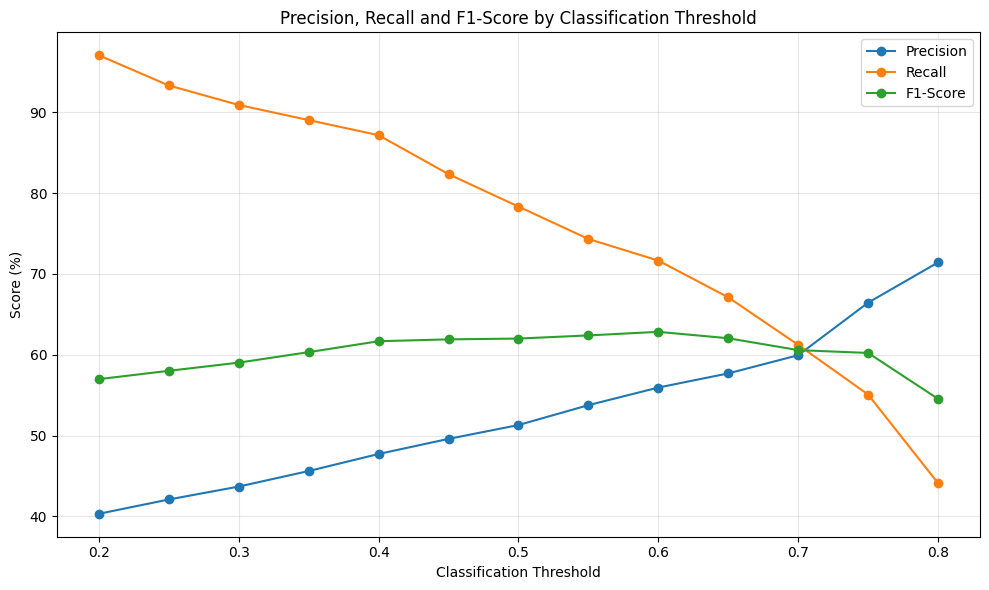

In [127]:
# Plot threshold performance

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df['Threshold'],
    threshold_results_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_results_df['Threshold'],
    threshold_results_df['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_results_df['Threshold'],
    threshold_results_df['F1-Score'],
    marker='o',
    label='F1-Score'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score (%)')
plt.title('Precision, Recall and F1-Score by Classification Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Final Model with Selected Threshold (0.60)

In [128]:
# Apply the selected probability threshold

selected_threshold = 0.60

final_y_pred = (
    y_pred_proba >= selected_threshold
).astype(int)

print("Selected threshold:", selected_threshold)
print("\nFinal prediction distribution:")
print(pd.Series(final_y_pred).value_counts().sort_index())

Selected threshold: 0.6

Final prediction distribution:
0    930
1    479
Name: count, dtype: int64


In [129]:
# Calculate final model metrics at threshold 0.60

final_accuracy = accuracy_score(
    y_test,
    final_y_pred
)

final_precision = precision_score(
    y_test,
    final_y_pred
)

final_recall = recall_score(
    y_test,
    final_y_pred
)

final_f1 = f1_score(
    y_test,
    final_y_pred
)

# ROC-AUC does not depend on the classification threshold
final_roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

print("Final Logistic Regression Performance")
print("--------------------------------------")
print(f"Threshold: {selected_threshold:.2f}")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

Final Logistic Regression Performance
--------------------------------------
Threshold: 0.60
Accuracy : 0.7750
Precision: 0.5595
Recall   : 0.7166
F1-score : 0.6284
ROC-AUC  : 0.8480


Final Confusion Matrix:
[[824 211]
 [106 268]]


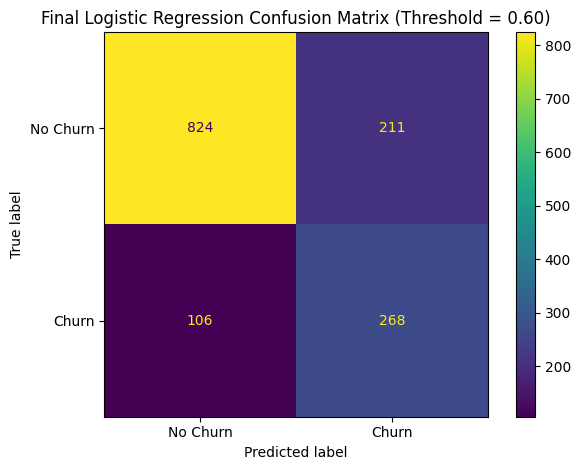

In [130]:
# Final confusion matrix at threshold 0.60

final_cm = confusion_matrix(
    y_test,
    final_y_pred
)

print("Final Confusion Matrix:")
print(final_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()
plt.title(
    'Final Logistic Regression Confusion Matrix '
    '(Threshold = 0.60)'
)
plt.tight_layout()
plt.show()

### Final Model Interpretation

In [131]:
# Extract feature names from the preprocessing pipeline

feature_names = best_logistic_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# Extract Logistic Regression coefficients

coefficients = best_logistic_model.named_steps[
    'model'
].coef_[0]

# Create feature importance dataframe

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Calculate absolute coefficient magnitude

feature_importance['Absolute Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

# Sort by absolute importance

feature_importance = feature_importance.sort_values(
    by='Absolute Coefficient',
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Coefficient,Absolute Coefficient
0,num__Tenure Months,-1.012838,1.012838
1,cat__Dependents_Yes,-0.769992,0.769992
2,cat__Dependents_No,0.768559,0.768559
3,cat__Contract_Month-to-month,0.694225,0.694225
4,cat__Contract_Two year,-0.618534,0.618534
5,cat__Internet Service_Fiber optic,0.354344,0.354344
6,num__Total Charges,0.291741,0.291741
7,cat__Payment Method_Electronic check,0.285846,0.285846
8,cat__Internet Service_DSL,-0.284888,0.284888
9,cat__Online Security_No,0.234663,0.234663


In [132]:
# Features associated with higher churn probability

positive_features = (
    feature_importance[
        feature_importance['Coefficient'] > 0
    ]
    .sort_values(
        by='Coefficient',
        ascending=False
    )
    .head(10)
)

# Features associated with lower churn probability

negative_features = (
    feature_importance[
        feature_importance['Coefficient'] < 0
    ]
    .sort_values(
        by='Coefficient',
        ascending=True
    )
    .head(10)
)

print("Top features associated with higher churn:")
display(positive_features)

print("\nTop features associated with lower churn:")
display(negative_features)

Top features associated with higher churn:


,Feature,Coefficient,Absolute Coefficient
2,cat__Dependents_No,0.768559,0.768559
3,cat__Contract_Month-to-month,0.694225,0.694225
5,cat__Internet Service_Fiber optic,0.354344,0.354344
6,num__Total Charges,0.291741,0.291741
7,cat__Payment Method_Electronic check,0.285846,0.285846
9,cat__Online Security_No,0.234663,0.234663
10,cat__Tech Support_No,0.216197,0.216197
14,cat__Paperless Billing_Yes,0.157755,0.157755
16,cat__Streaming Movies_Yes,0.137527,0.137527
17,cat__Streaming TV_Yes,0.132137,0.132137



Top features associated with lower churn:


,Feature,Coefficient,Absolute Coefficient
0,num__Tenure Months,-1.012838,1.012838
1,cat__Dependents_Yes,-0.769992,0.769992
4,cat__Contract_Two year,-0.618534,0.618534
8,cat__Internet Service_DSL,-0.284888,0.284888
11,cat__Multiple Lines_No,-0.178465,0.178465
12,cat__Online Security_Yes,-0.165207,0.165207
13,cat__Paperless Billing_No,-0.159187,0.159187
15,cat__Tech Support_Yes,-0.146741,0.146741
18,cat__Partner_No,-0.123155,0.123155
20,cat__Payment Method_Credit card (automatic),-0.121712,0.121712


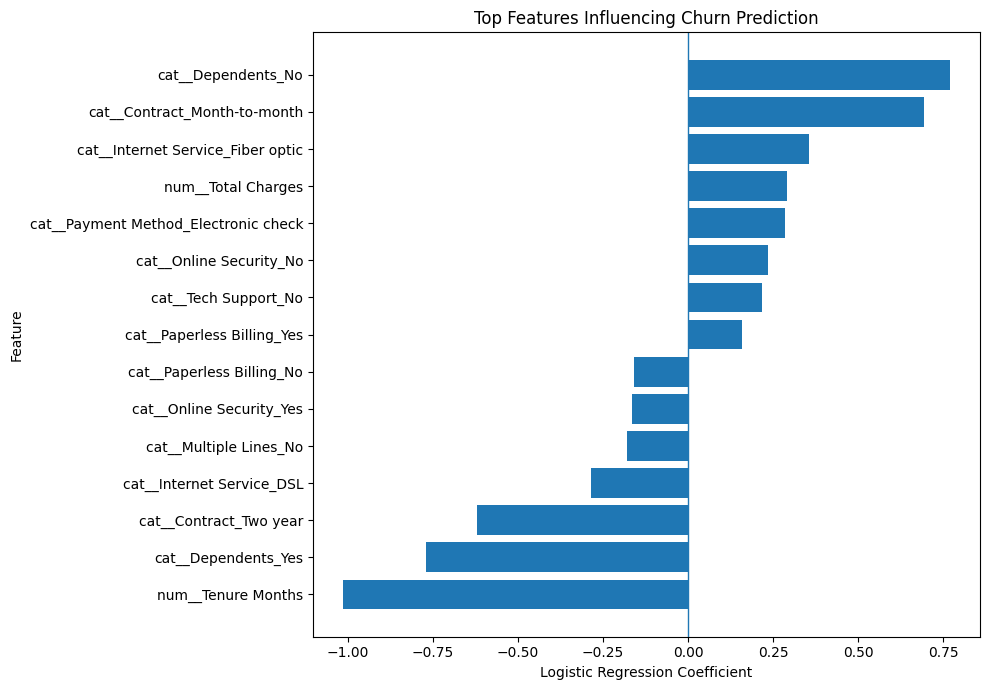

In [133]:
# Select top 15 features by absolute coefficient

top_features = (
    feature_importance
    .head(15)
    .sort_values(
        by='Coefficient'
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('Feature')
plt.title(
    'Top Features Influencing Churn Prediction'
)

plt.tight_layout()
plt.show()